# Notebook 01 — Feature Engineering & EDA
Limpieza, análisis exploratorio, ingeniería de variables y exportación de sets procesados.

In [1]:
import sys, os, warnings
warnings.filterwarnings('ignore')
sys.path.append(os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from statsmodels.stats.outliers_influence import variance_inflation_factor
import joblib

from src.data_processing import clean_and_engineer_features, preprocess_data

SEED = 42
np.random.seed(SEED)
sns.set_theme(style='whitegrid', palette='muted')
print('Librerías cargadas correctamente.')


Librerías cargadas correctamente.


## 1. Carga de datos

In [2]:
train_raw = pd.read_csv('../data/raw/train.csv')
test_raw  = pd.read_csv('../data/raw/test.csv')

print(f'Train: {train_raw.shape}  |  Test: {test_raw.shape}')
print('\n=== Primeras filas del train ===')
display(train_raw.head(3))
print('\n=== Tipos de dato ===')
display(train_raw.dtypes.to_frame('dtype'))

Train: (5634, 21)  |  Test: (1409, 20)

=== Primeras filas del train ===


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,4950-BDEUX,Male,0,No,No,35,No,No phone service,DSL,No,...,Yes,No,Yes,Yes,Month-to-month,No,Electronic check,49.20,1701.65,No
1,7993-NQLJE,Male,0,Yes,Yes,15,Yes,No,Fiber optic,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,75.10,1151.55,No
2,7321-ZNSLA,Male,0,Yes,Yes,13,No,No phone service,DSL,Yes,...,No,Yes,No,No,Two year,No,Mailed check,40.55,590.35,No



=== Tipos de dato ===


,dtype
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


## 2. Estadísticas descriptivas y valores nulos

In [3]:
print('=== Valores nulos antes de limpieza ===')
nulos = train_raw.isnull().sum()
print(nulos[nulos > 0])

print('\n=== TotalCharges vacíos (strings) ===')
vacios = (train_raw['TotalCharges'].str.strip() == '').sum()
print(f'Valores faltantes: {vacios}')

print('\n=== Distribución de la variable objetivo ===')
display(train_raw['Churn'].value_counts(normalize=True).rename('proporcion').to_frame())

=== Valores nulos antes de limpieza ===
Series([], dtype: int64)

=== TotalCharges vacíos (strings) ===
Valores faltantes: 8

=== Distribución de la variable objetivo ===


,proporcion
Churn,
No,0.734647
Yes,0.265353


## 3. Limpieza y Feature Engineering

In [4]:
train_clean = clean_and_engineer_features(train_raw, is_train=True)
test_clean  = clean_and_engineer_features(test_raw,  is_train=False)

nuevas_vars = [
    'Tenure_to_Charge_Ratio', 'Charge_Growth', 'Total_Addons',
    'Risk_Fiber_NoSupport', 'Is_ManualPayment', 'Solo_User',
    'Tenure_Bin', 'Contract_Ordinal'
]
print('=== Nuevas variables creadas ===')
display(train_clean[nuevas_vars].head(5))

=== Nuevas variables creadas ===


,Tenure_to_Charge_Ratio,Charge_Growth,Total_Addons,Risk_Fiber_NoSupport,Is_ManualPayment,Solo_User,Tenure_Bin,Contract_Ordinal
0,0.711382,1.011959,3,0,1,1,3,0
1,0.199734,0.978247,1,1,1,0,2,0
2,0.320592,0.892945,3,0,1,0,2,2
3,0.353741,1.002781,4,0,0,0,3,2
4,0.022447,1.000010,0,0,1,0,0,0


## 4. Split train

In [5]:
# Split estratificado 80/20
train_local_df, val_local_df = train_test_split(
    train_clean, test_size=0.2, random_state=SEED,
    stratify=train_clean['Churn']
)

## 4. Distribución de variables numéricas (antes y después de Yeo-Johnson)

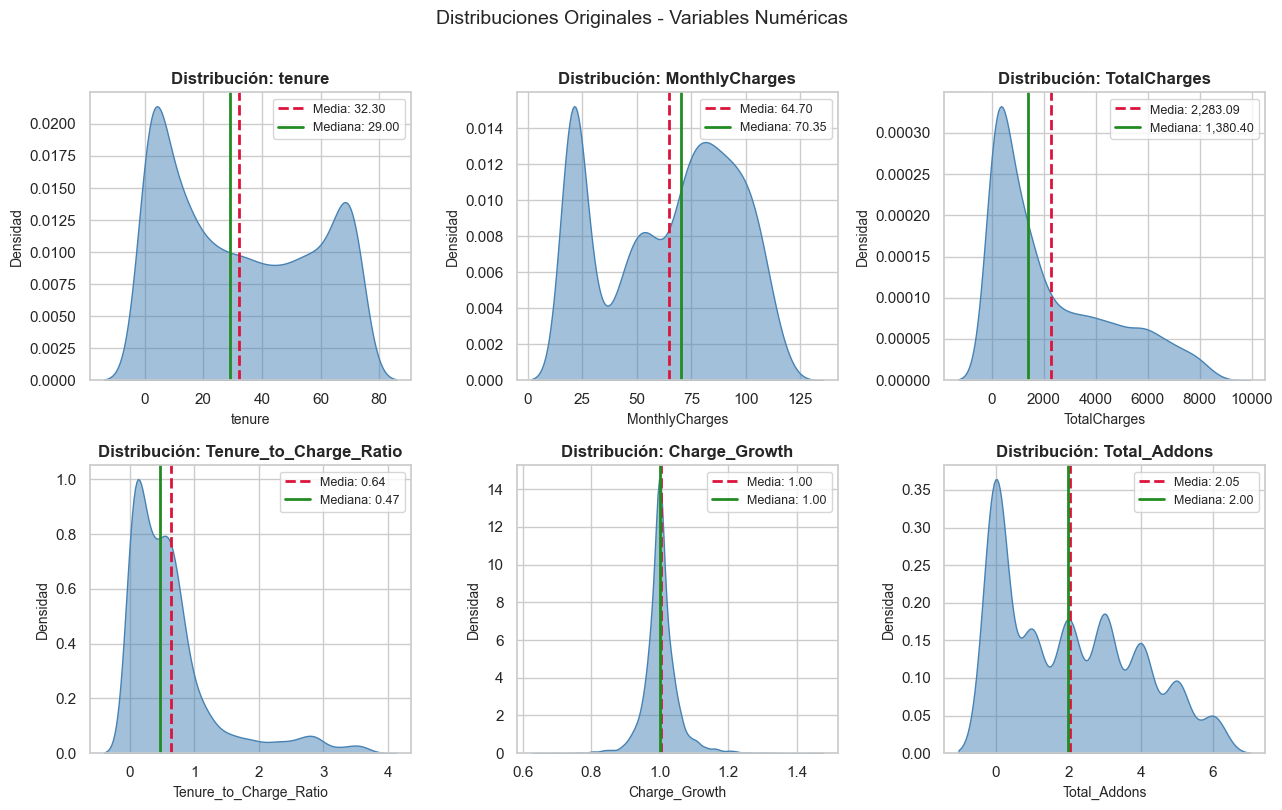

In [6]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Tenure_to_Charge_Ratio', 'Charge_Growth',
        'Total_Addons']

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.kdeplot(train_local_df[col], fill=True, color='steelblue', alpha=0.5, ax=axes[i])
    axes[i].axvline(train_local_df[col].mean(),   color='crimson', ls='--', lw=2, label=f'Media: {train_local_df[col].mean():,.2f}')
    axes[i].axvline(train_local_df[col].median(), color='forestgreen', ls='-', lw=2, label=f'Mediana: {train_local_df[col].median():,.2f}')
    axes[i].set_title(f'Distribución: {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel('Densidad', fontsize=10)
    axes[i].legend(fontsize=9)
plt.suptitle('Distribuciones Originales - Variables Numéricas', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../data/processed/fig_distribuciones_raw.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# Evaluar necesidad de transformación de datos
pt_report = PowerTransformer(method='yeo-johnson', standardize=False)
pt_report.fit(train_local_df[num_cols]) 

lambdas_df = pd.DataFrame({
    'Variable Numérica': num_cols,
    'Skewness Original': train_local_df[num_cols].skew().values,
    'Lambda Óptimo (Yeo-Johnson)': pt_report.lambdas_
})

display(lambdas_df)

,Variable Numérica,Skewness Original,Lambda Óptimo (Yeo-Johnson)
0,tenure,0.245884,0.438978
1,MonthlyCharges,-0.217930,0.924367
2,TotalCharges,0.951705,0.253161
3,Tenure_to_Charge_Ratio,2.091543,-1.321037
4,Charge_Growth,0.663530,-1.017746
5,Total_Addons,0.447896,0.207113


## 6. Validation y preprocesamiento

In [8]:
# Preprocesamiento (encoding + scaling)
X_train, X_val, X_test_kaggle, y_train, y_val, test_ids, scaler = preprocess_data(
    train_local_df, val_local_df, test_clean
)

print(f'X_train: {X_train.shape}  |  X_val: {X_val.shape}  |  X_test: {X_test_kaggle.shape}')
print(f'Churn rate train: {y_train.mean():.3f}  |  val: {y_val.mean():.3f}')

X_train: (4507, 31)  |  X_val: (1127, 31)  |  X_test: (1409, 31)
Churn rate train: 0.265  |  val: 0.265


## 6. Multicolinealidad — VIF (variables numéricas)


--- VIF de Variables Cuantitativas ---


,Variable,VIF
0,tenure,100.053475
1,TotalCharges,66.016026
2,Tenure_to_Charge_Ratio,30.371793
3,MonthlyCharges,11.742651
4,Total_Addons,3.165165
5,Charge_Growth,1.042185


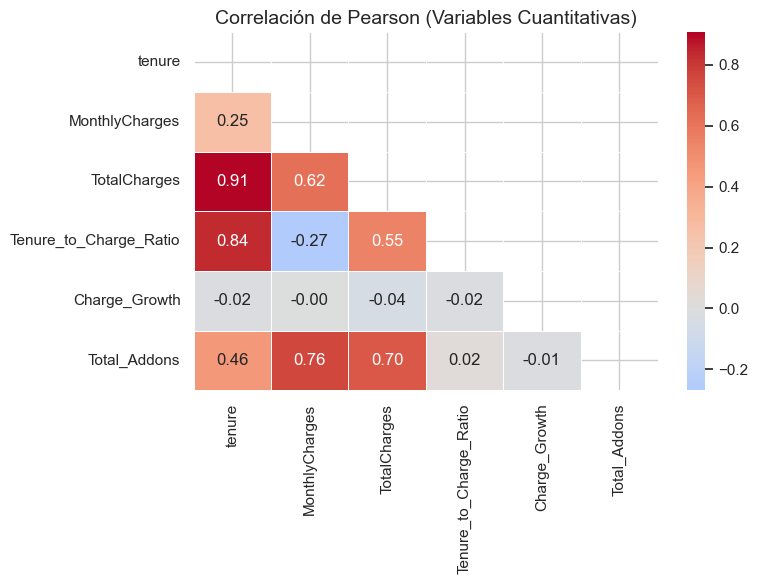

In [9]:
# MULTICOLINEALIDAD - VARIABLES NUMÉRICAS

X_train_num = X_train[num_cols].astype(float)

# Cálculo VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = X_train_num.columns
vif_data["VIF"] = [variance_inflation_factor(X_train_num.values, i) for i in range(len(X_train_num.columns))]
vif_data = vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True)

print("\n--- VIF de Variables Cuantitativas ---")
display(vif_data)

# 6. Heatmap de Correlación de Pearson
plt.figure(figsize=(8, 6))
corr_matrix_num = X_train_num.corr(method='pearson')
mask = np.triu(np.ones_like(corr_matrix_num, dtype=bool))
sns.heatmap(corr_matrix_num, mask=mask, cmap='coolwarm', center=0, annot=True, fmt=".2f", linewidths=.5)
plt.title('Correlación de Pearson (Variables Cuantitativas)', fontsize=14)
plt.tight_layout()
plt.show()

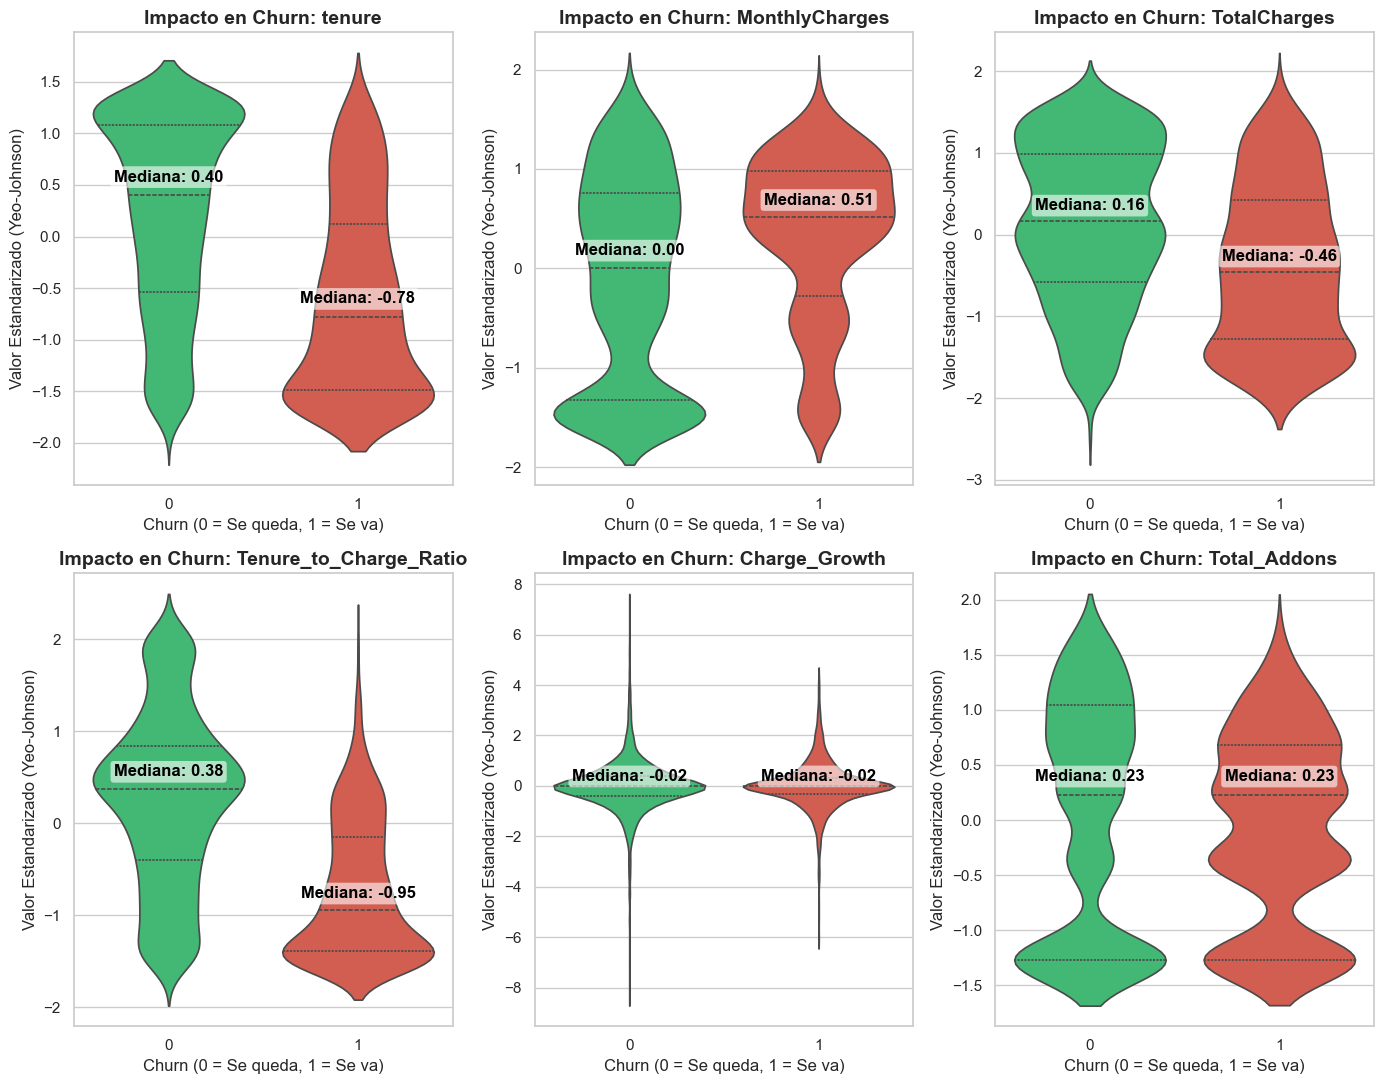

In [10]:
# IMPACTO DE VARIABLES NUMERICAS PREDICTORAS EN CHURN

df_viz = X_train_num.copy()
df_viz['Churn'] = y_train.values 


fig, axes = plt.subplots(2, 3, figsize=(14, 11))
axes = axes.flatten()
sns.set_theme(style="whitegrid")

colores_churn = ['#2ecc71', '#e74c3c']

for i, col in enumerate(num_cols):
    sns.violinplot(
        x='Churn', 
        y=col, 
        data=df_viz, 
        ax=axes[i], 
        hue='Churn',
        legend=False,
        palette=colores_churn, 
        inner='quartile' 
    )
    
    # Calculamos la mediana real para Churn=0 y Churn=1
    mediana_0 = df_viz[df_viz['Churn'] == 0][col].median()
    mediana_1 = df_viz[df_viz['Churn'] == 1][col].median()
    
    # Colocar el texto sobre el gráfico (x=0 para No Churn, x=1 para Churn)
    axes[i].text(0, mediana_0 + 0.1, f'Mediana: {mediana_0:.2f}', 
                 color='black', weight='bold', ha='center', va='bottom',
                 bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', boxstyle='round,pad=0.2'))
    
    axes[i].text(1, mediana_1 + 0.1, f'Mediana: {mediana_1:.2f}', 
                 color='black', weight='bold', ha='center', va='bottom',
                 bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', boxstyle='round,pad=0.2'))
    # -----------------------------------------------------------
    
    axes[i].set_title(f'Impacto en Churn: {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Churn (0 = Se queda, 1 = Se va)', fontsize=12)
    axes[i].set_ylabel('Valor Estandarizado (Yeo-Johnson)', fontsize=12)

plt.tight_layout()
plt.show()

## 7. Relevancia categórica (Chi-Cuadrado vs Churn)

In [11]:
cat_cols = [c for c in X_train.columns if X_train[c].nunique() <= 5]
resultados_chi2 = []

for col in cat_cols:
    ct = pd.crosstab(X_train[col], y_train)
    chi2, p, _, _ = chi2_contingency(ct)
    resultados_chi2.append({'Variable': col, 'p-value': round(p, 6),
                             'Relevante': 'Sí' if p < 0.05 else 'No'})

df_chi2 = pd.DataFrame(resultados_chi2).sort_values('p-value').reset_index(drop=True)
display(df_chi2)

,Variable,p-value,Relevante
0,SeniorCitizen,0.000000,Sí
1,Partner,0.000000,Sí
2,Dependents,0.000000,Sí
3,OnlineSecurity,0.000000,Sí
4,OnlineBackup,0.000000,Sí
5,Is_ManualPayment,0.000000,Sí
6,PaperlessBilling,0.000000,Sí
7,TechSupport,0.000000,Sí
8,Solo_User,0.000000,Sí
9,Tenure_Bin,0.000000,Sí


## 8. Importancia de variables (Random Forest proxy)

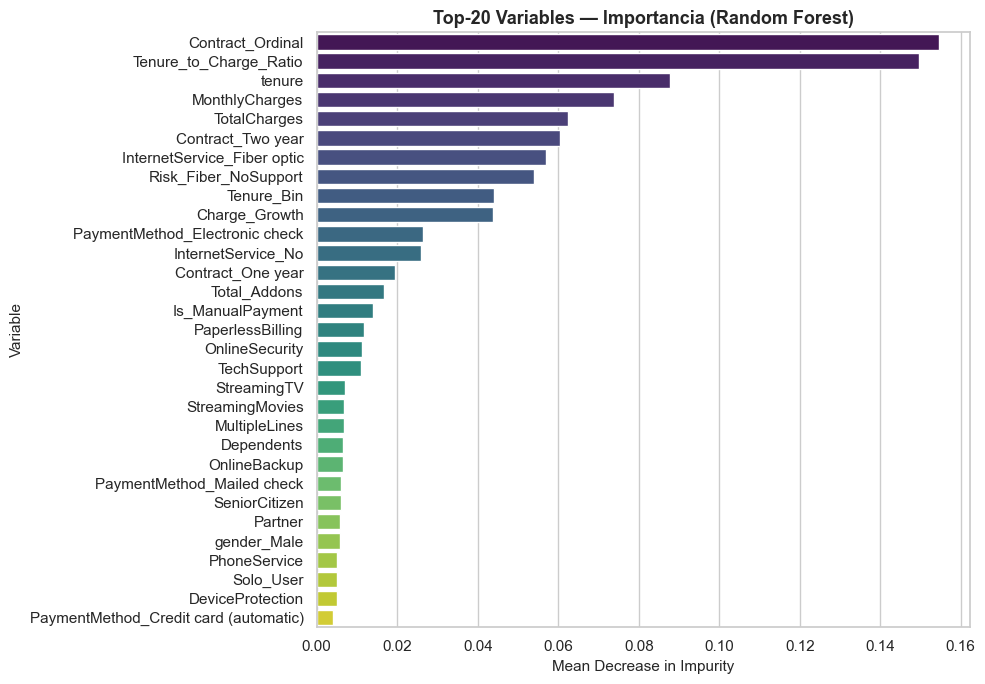

In [12]:
rf_proxy = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=SEED,
                                   class_weight='balanced', n_jobs=-1)
rf_proxy.fit(X_train, y_train)

importancias = pd.DataFrame({
    'Variable': X_train.columns,
    'Importancia': rf_proxy.feature_importances_
}).sort_values('Importancia', ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 7))
sns.barplot(x='Importancia', y='Variable', data=importancias, palette='viridis', hue='Variable', legend=False)
plt.title('Top-20 Variables — Importancia (Random Forest)', fontsize=13, fontweight='bold')
plt.xlabel('Mean Decrease in Impurity', fontsize=11)
plt.ylabel('Variable', fontsize=11)
plt.tight_layout()
plt.savefig('../data/processed/fig_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Desbalanceo de clases

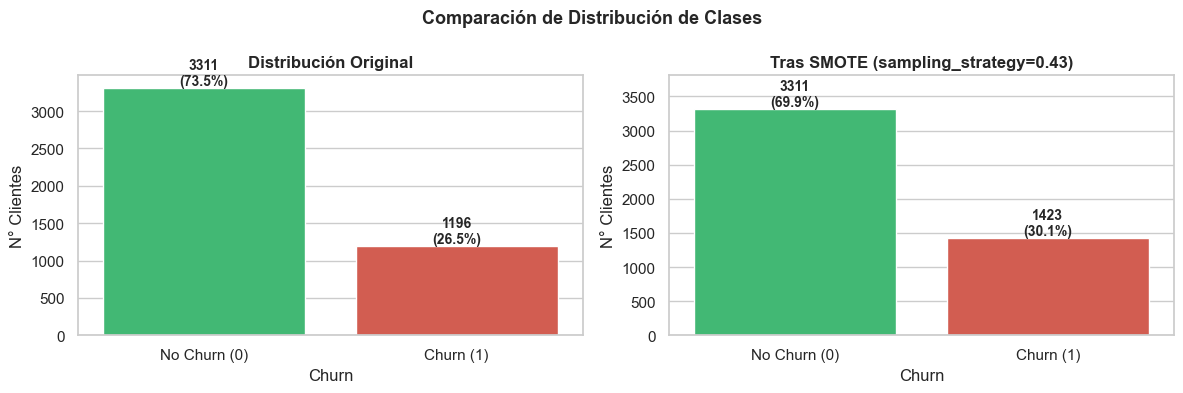

Original: 3311 (73.5%)  |  Churn: 1196 (26.5%)
Tras SMOTE: 3311 (69.9%)  |  Churn: 1423 (30.1%)


In [13]:
# Distribución original 
conteos = y_train.value_counts()
pcts    = y_train.value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Antes de SMOTE
ax = axes[0]
sns.countplot(x=y_train, palette=['#2ecc71', '#e74c3c'], hue=y_train, legend=False, ax=ax)
ax.set_title('Distribución Original', fontsize=12, fontweight='bold')
ax.set_xticks([0, 1])
ax.set_xticklabels(['No Churn (0)', 'Churn (1)'])
ax.set_ylabel('N° Clientes')
for p in ax.patches:
    h = p.get_height()
    ax.annotate(f'{int(h)}\n({100*h/len(y_train):.1f}%)',
                (p.get_x() + p.get_width()/2, h),
                ha='center', va='bottom', fontweight='bold', fontsize=10)

# SMOTE aplicado
SEED = 42
smote = SMOTE(random_state=SEED, sampling_strategy=0.43)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

conteos_sm = pd.Series(y_train_sm).value_counts()
ax2 = axes[1]
sns.countplot(x=y_train_sm, palette=['#2ecc71', '#e74c3c'], hue=y_train_sm, legend=False, ax=ax2)
ax2.set_title('Tras SMOTE (sampling_strategy=0.43)', fontsize=12, fontweight='bold')
ax2.set_xticks([0, 1])
ax2.set_xticklabels(['No Churn (0)', 'Churn (1)'])
ax2.set_ylabel('N° Clientes')
ax2.set_ylim(0, max(conteos_sm) * 1.15)
for p in ax2.patches:
    h = p.get_height()
    ax2.annotate(f'{int(h)}\n({100*h/len(y_train_sm):.1f}%)',
                 (p.get_x() + p.get_width()/2, h),
                 ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.suptitle('Comparación de Distribución de Clases', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/fig_smote_balance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Original: {conteos[0]} ({pcts[0]:.1f}%)  |  Churn: {conteos[1]} ({pcts[1]:.1f}%)")
print(f"Tras SMOTE: {conteos_sm[0]} ({100*conteos_sm[0]/len(y_train_sm):.1f}%)  |  Churn: {conteos_sm[1]} ({100*conteos_sm[1]/len(y_train_sm):.1f}%)")

--- Distribución antes de SMOTE ---
  Clase 0: 3311 (73.5%)
  Clase 1: 1196 (26.5%)


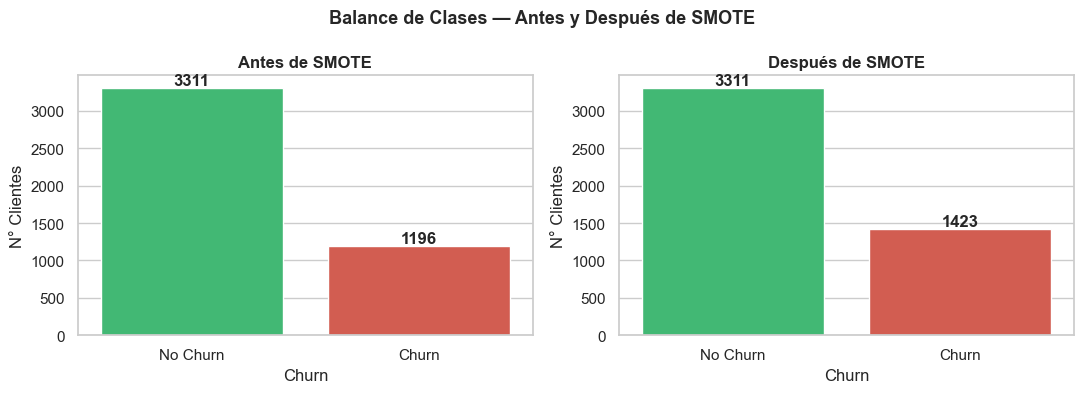


Train tras SMOTE: (4734, 31) | Churn rate: 0.301


In [14]:
conteos = y_train.value_counts()
pcts    = y_train.value_counts(normalize=True) * 100

print('--- Distribución antes de SMOTE ---')
for c, n in conteos.items():
    print(f'  Clase {c}: {n} ({pcts[c]:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Antes
ax = axes[0]
sns.countplot(x=y_train, palette=['#2ecc71', '#e74c3c'], hue=y_train, legend=False, ax=ax)
ax.set_title('Antes de SMOTE', fontsize=12, fontweight='bold')
ax.set_xticks([0, 1]); ax.set_xticklabels(['No Churn', 'Churn'])
ax.set_ylabel('N° Clientes')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontweight='bold')

# Aplicar SMOTE  (30% churn tras oversampling)
smote = SMOTE(random_state=SEED, sampling_strategy=0.43)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

conteos_sm = pd.Series(y_train_sm).value_counts()
ax2 = axes[1]
sns.countplot(x=y_train_sm, palette=['#2ecc71', '#e74c3c'], hue=y_train_sm, legend=False, ax=ax2)
ax2.set_title('Después de SMOTE', fontsize=12, fontweight='bold')
ax2.set_xticks([0, 1]); ax2.set_xticklabels(['No Churn', 'Churn'])
ax2.set_ylabel('N° Clientes')
for p in ax2.patches:
    ax2.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                 ha='center', va='bottom', fontweight='bold')

plt.suptitle('Balance de Clases — Antes y Después de SMOTE', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/fig_smote_balance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nTrain tras SMOTE: {X_train_sm.shape} | Churn rate: {y_train_sm.mean():.3f}')


## 10. Exportar artefactos

In [15]:
os.makedirs('../data/processed', exist_ok=True)

# Ruta sin SMOTE (class_weight='balanced' en los modelos se encarga del desbalance)
joblib.dump(X_train,       '../data/processed/X_train.pkl')
joblib.dump(y_train,       '../data/processed/y_train.pkl')

# Ruta con SMOTE (alternativa para comparar en el experimento)
joblib.dump(X_train_sm,    '../data/processed/X_train_sm.pkl')
joblib.dump(y_train_sm,    '../data/processed/y_train_sm.pkl')

# Compartidos por ambas rutas
joblib.dump(X_val,         '../data/processed/X_val.pkl')
joblib.dump(X_test_kaggle, '../data/processed/X_test_kaggle.pkl')
joblib.dump(y_val,         '../data/processed/y_val.pkl')
joblib.dump(test_ids,      '../data/processed/test_ids.pkl')
joblib.dump(scaler,        '../data/processed/scaler.pkl')

print('- Artefactos exportados a data/processed/')
print(f'   X_train       (sin SMOTE): {X_train.shape}    | churn rate: {y_train.mean():.3f}')
print(f'   X_train_sm    (con SMOTE): {X_train_sm.shape} | churn rate: {y_train_sm.mean():.3f}')
print(f'   X_val                    : {X_val.shape}')
print(f'   X_test_kaggle            : {X_test_kaggle.shape}')


- Artefactos exportados a data/processed/
   X_train       (sin SMOTE): (4507, 31)    | churn rate: 0.265
   X_train_sm    (con SMOTE): (4734, 31) | churn rate: 0.301
   X_val                    : (1127, 31)
   X_test_kaggle            : (1409, 31)
